Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


np.int64(0)


The outliers for price_usd are:-


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification


...


The outliers for Sales_Volume are:-


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000
mean,100307.203140,75034.600900,5067.514680
std,57941.509344,25998.248882,2856.767125
min,3.000000,30000.000000,100.000000
25%,50178.000000,52434.750000,2588.000000
50%,100388.500000,75011.500000,5087.000000
75%,150630.250000,97628.250000,7537.250000
max,199996.000000,119998.000000,9999.000000


We used boxplots to compare spread, median, and outliers of units sold across various BMW models.
Box plots are used to visualize the  spread of numerical data.


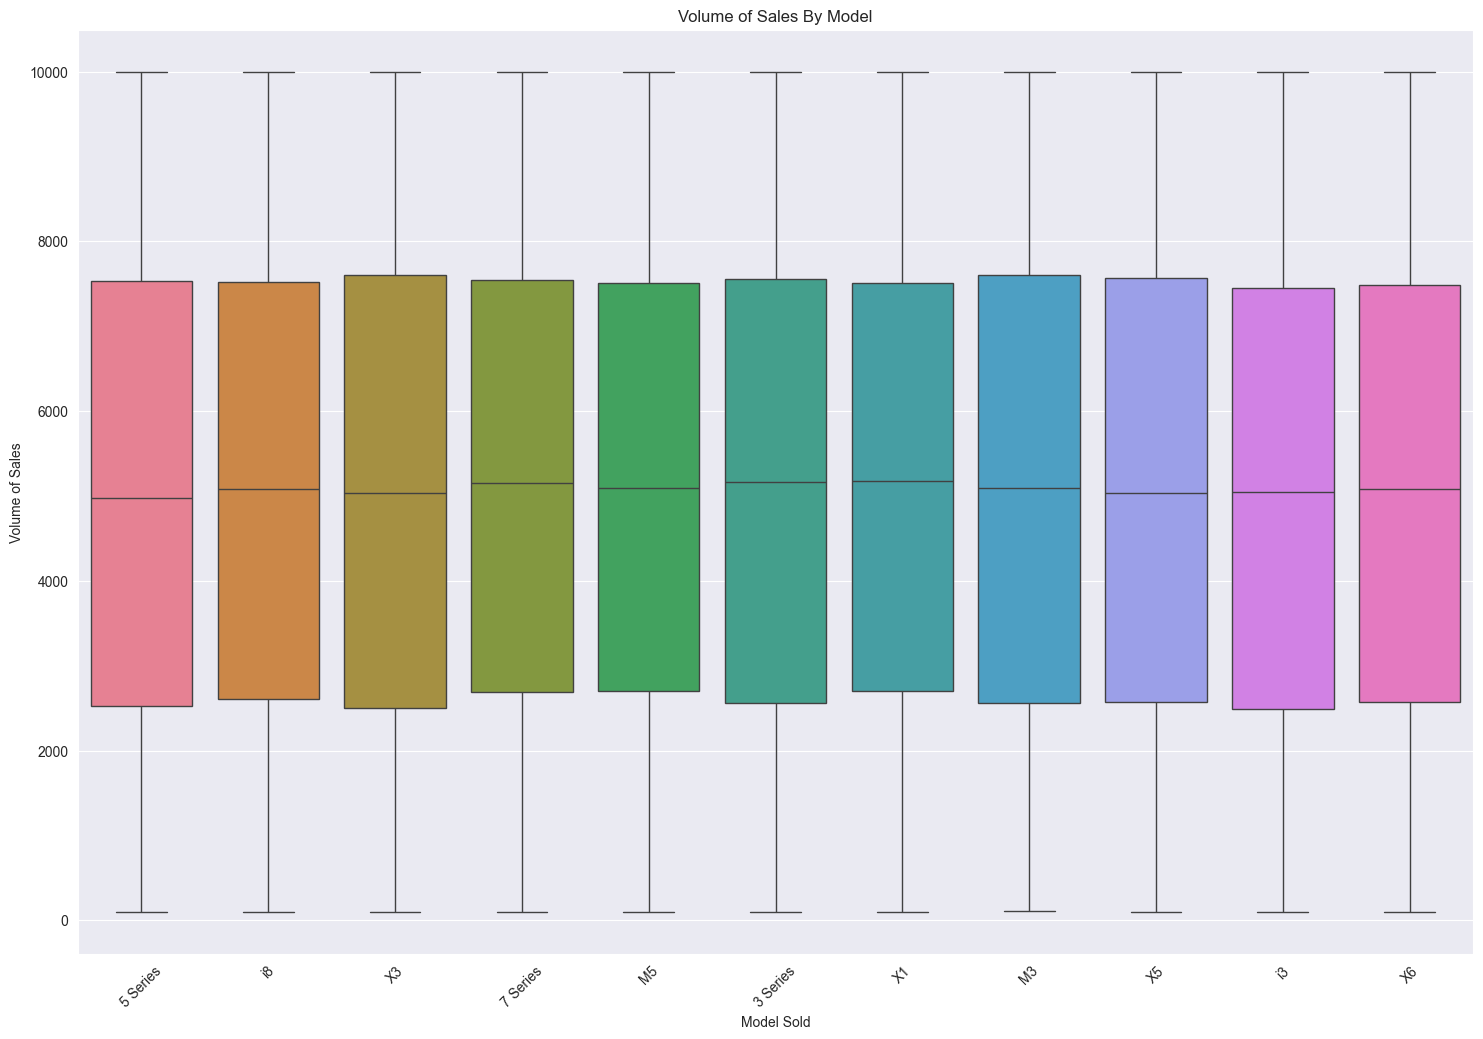

We used lineplot to show the trend of sales over time.


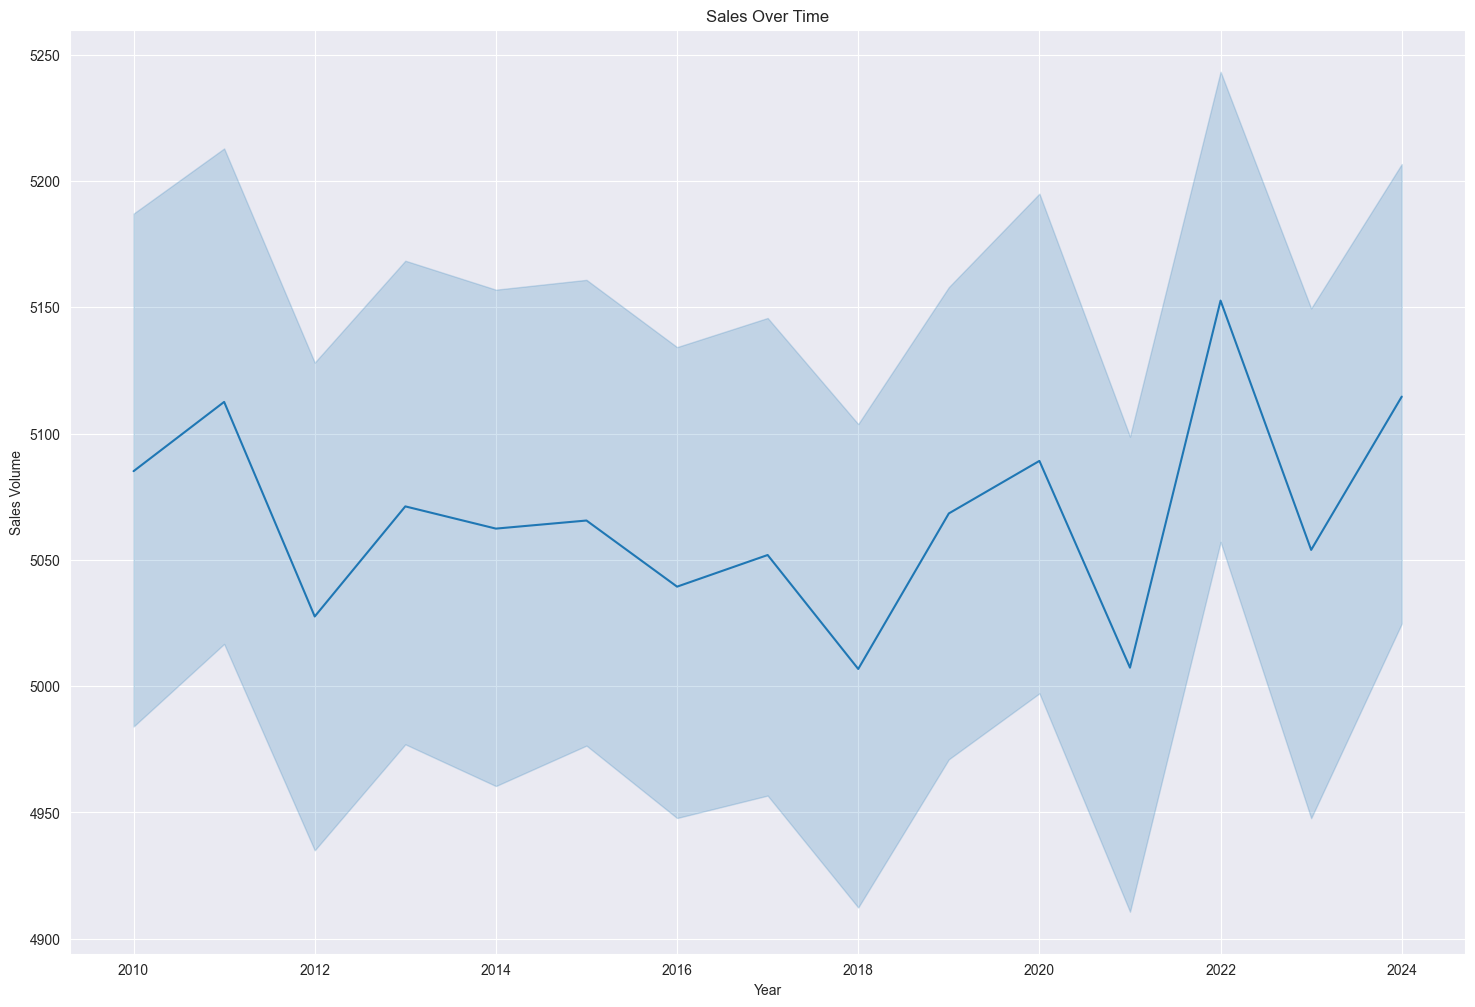

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Data Source -https://www.kaggle.com/datasets/ahmadrazakashif/bmw-worldwide-sales-records-20102024

df=pd.read_csv('C:\\BMW.csv')

#2.	Data Cleaning: 
#This is to fill the missing numeric values in the data with mean
display(df.isnull().sum())
df.fillna(df.select_dtypes(include="number").mean(), inplace=True)  
# display(df)

#This is to drop any remaining missing values which have not be been filled
df.dropna(inplace = True)
display(df)

# Checked for duplicate values in the DataFrame.
display(df.duplicated().sum())
df.drop_duplicates()

#Identifying and Handling Outliers for Price_USD Column.
Q1 = df['Price_USD'].quantile(0.25)
Q3 = df['Price_USD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Price_USD'] < lower_bound) | (df['Price_USD'] > upper_bound)]
print(f'\nThe outliers for price_usd are:-')
display(outliers_iqr)
df = df[(df['Price_USD'] >= lower_bound) & (df['Price_USD'] <= upper_bound)]
display(df)

#Identifying and Handling Outliers for Sales_Volume Column.
Q1 = df['Sales_Volume'].quantile(0.25)
Q3 = df['Sales_Volume'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['Sales_Volume'] < lower_bound) | (df['Sales_Volume'] > upper_bound)]
print(f'\nThe outliers for Sales_Volume are:-')
display(outliers_iqr)
df = df[(df['Sales_Volume'] >= lower_bound) & (df['Sales_Volume'] <= upper_bound)]
display(df)

#3.	Exploratory Data Analysis (EDA): 
#Descriptive Statistics
display(df.drop(columns=['Year','Engine_Size_L']).describe())


# Data Visualization
print("We used boxplots to compare spread, median, and outliers of units sold across various BMW models.\n"
    "Box plots are used to visualize the  spread of numerical data.")
plt.figure(figsize=(18,12))
sns.set_style('darkgrid')
sns.boxplot(x=df['Model'],y= df['Sales_Volume'],hue=df['Model'])
plt.xlabel('Model Sold')
plt.ylabel('Volume of Sales')
plt.title('Volume of Sales By Model')
plt.xticks(rotation =45)
plt.show()


# Correlation Analysis
numerical_columns = df.drop(columns=['Year']).select_dtypes(include=[np.number]).columns
df[numerical_columns].corr()

# Hypothesis Testing
# FuelType vs AveragePrice
print("H₀: There is no significant difference in average vehicle price between fuel types (Petrol, Diesel, Electric).\n")
    "Ha: At least one fuel type has a different average price.")

# Region vs AveragePrice
print(" H₀: The average vehicle price is the same across all regions.\n"
    "Ha: At least one region differs in mean price.")

# FuelType vs Transmission
print("H₀: Fuel type and transmission are independent.\n"
    "Ha: Fuel type and transmission are associated.")

#Time series Analysis
print("We used lineplot to show the trend of sales over time.")
plt.figure(figsize=(18,12))
sns.set_style('darkgrid')
sns.lineplot(x = df['Year'],y= df['Sales_Volume'])
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Sales Over Time')
plt.show()